Entries: 150000
******************************************************************************
*Tree    :t         : Geant4 step points                                     *
*Entries :   150000 : Total =       361353876 bytes  File  Size =   87155993 *
*        :          : Tree compression factor =   4.15                       *
******************************************************************************
*Br    0 :n         : Int_t t                                                *
*Entries :   150000 : Total  Size=    1202183 bytes  File Size  =     331788 *
*Baskets :       18 : Basket Size=      32000 bytes  Compression=   3.48     *
*............................................................................*
*Br    1 :m         : Int_t t                                                *
*Entries :   150000 : Total  Size=    1202183 bytes  File Size  =     309440 *
*Baskets :       18 : Basket Size=      32000 bytes  Compression=   3.73     *
*...................................

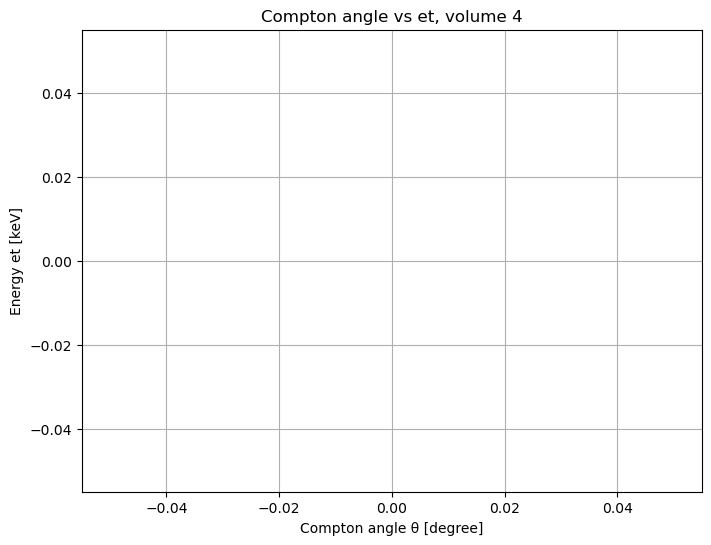

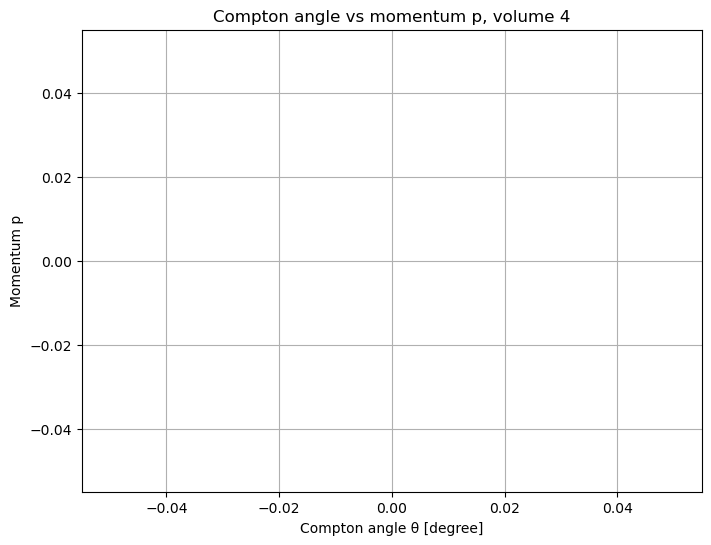

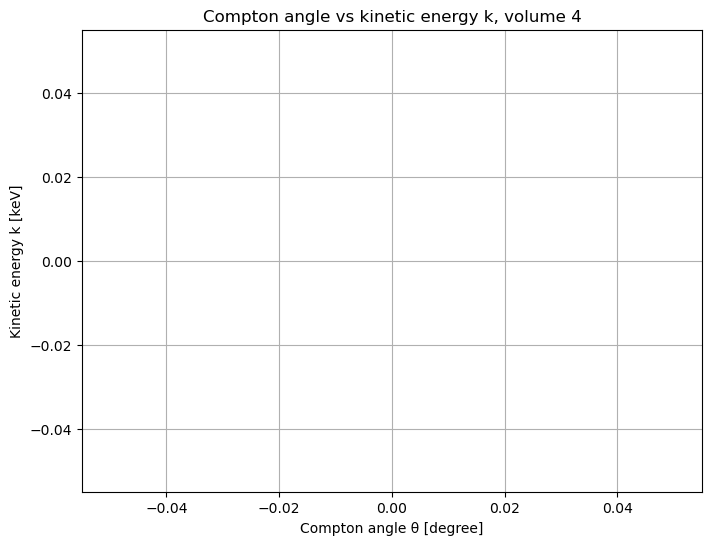

In [1]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
root_file = "sucrose.root"
tree_name = "t"

volume_id = 4
pdg_code = 22          # gamma
compton_code = 2013

E0 = 662.0             # keV
me = 511.0             # keV

# =========================
# OPEN ROOT FILE
# =========================
f = ROOT.TFile.Open(root_file)
if not f or f.IsZombie():
    raise RuntimeError(f"Could not open ROOT file: {root_file}")

t = f.Get(tree_name)
if not t:
    raise RuntimeError(f"Could not find tree {tree_name}")

print("Entries:", t.GetEntries())
t.Print()

# =========================
# ARRAYS
# =========================
theta_list = []
et_list = []
p_list = []
k_list = []

# =========================
# LOOP OVER TREE
# =========================
for entry in t:

    n = min(len(entry.pdg), len(entry.vlm), len(entry.et), len(entry.p), len(entry.k), len(entry.pro))

    for i in range(n):

        # gamma only
        if int(entry.pdg[i]) != pdg_code:
            continue

        # Compton only
        if int(entry.pro[i]) != compton_code:
            continue

        # volume 4 only
        if int(entry.vlm[i]) != volume_id:
            continue

        Es = float(entry.et[i])   # scattered gamma energy

        if Es <= 0 or Es >= E0:
            continue

        # Compton angle from energy
        cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

        if cos_theta < -1.0 or cos_theta > 1.0:
            continue

        theta_deg = math.degrees(math.acos(cos_theta))

        theta_list.append(theta_deg)
        et_list.append(float(entry.et[i]))
        p_list.append(float(entry.p[i]))
        k_list.append(float(entry.k[i]))

f.Close()

theta = np.array(theta_list)
et = np.array(et_list)
p = np.array(p_list)
k = np.array(k_list)

print("Selected points:", len(theta))

# =========================
# PLOT 1: THETA vs et
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(theta, et, s=8, alpha=0.5)
plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Energy et [keV]")
plt.title("Compton angle vs et, volume 4")
plt.grid(True)
plt.show()

# =========================
# PLOT 2: THETA vs momentum p
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(theta, p, s=8, alpha=0.5)
plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Momentum p")
plt.title("Compton angle vs momentum p, volume 4")
plt.grid(True)
plt.show()

# =========================
# PLOT 3: THETA vs kinetic energy k
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(theta, k, s=8, alpha=0.5)
plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Kinetic energy k [keV]")
plt.title("Compton angle vs kinetic energy k, volume 4")
plt.grid(True)
plt.show()